# Vote concentration and population density by commune — 2002 & 2022

At département level, HHI (and CENP) shows no association with population density in 2002 but a positive one in
2022. **Does the same pattern appear at commune level?**

Reads `data/processed/coordination_density_communes_corrected.csv` (built by `scripts/01`–`04`). 2002 and 2022 are
analysed as **two separate cross-sections** (no commune-level change). Everything is descriptive: associations, not
causal effects, and concentration is not by itself evidence of strategic voting.

**Outcomes** (definitions in `svgeo/indices.py`):

* `HHI` $=\sum_j s_j^2$ — main measure: the observed concentration of the commune's first-round vote;
* `HHI_corrected` $=\sum_j n_j(n_j-1)/(n(n-1))$ — used to check whether results are driven by the mechanical
  concentration of small electorates. With $n$ votes drawn from shares $p$, $E[\text{HHI}] = \sum p_j^2 +
  (1-\sum p_j^2)/n$, while $E[\text{HHI}_\text{corrected}] = \sum p_j^2$. HHI describes the realised result;
  corrected HHI estimates the underlying concentration net of finite-electorate noise. Neither is "the" correct one;
* `CENP` — supplementary normalised measure, kept as a continuity and robustness check (within one election it orders
  communes exactly as HHI does).

**Main samples** (`main_sample`): metropolitan communes matched to INSEE, with finite log density and CENP, excluding
2002 communes flagged as possible boundary changes (registered / population outside [0.4, 1.2]). 2002 density uses
`population_2002_interp` (1999–2006 geometric interpolation), 2022 density uses the 2022 population.
Unweighted results are the main specification; WLS (weights = expressed votes) is a robustness check.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from svgeo.analysis import association_stats, commune_scatter, fe_stats, pooled_interaction, show_plot
from svgeo.config import COMMUNE_DENSITY, YEARS
from svgeo.utils import read_csv

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

OUTCOMES = {"HHI": "HHI", "HHI_corrected": "Corrected HHI", "CENP": "CENP (continuity)"}

merged = read_csv(COMMUNE_DENSITY)
main = merged[merged["main_sample"]].copy()
counts = merged.groupby("year").agg(all=("commune_code", "size"), main_sample=("main_sample", "sum"))
counts["main_sample_without_HHI_corrected"] = main["HHI_corrected"].isna().groupby(main["year"]).sum()  # n <= 1
counts

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,all,main_sample,main_sample_without_HHI_corrected
year,,,
2002,36674,33581,0
2022,35034,34112,0


## 1. Vote concentration and density in each year

HHI (main), corrected HHI and CENP against log density, one panel per outcome.

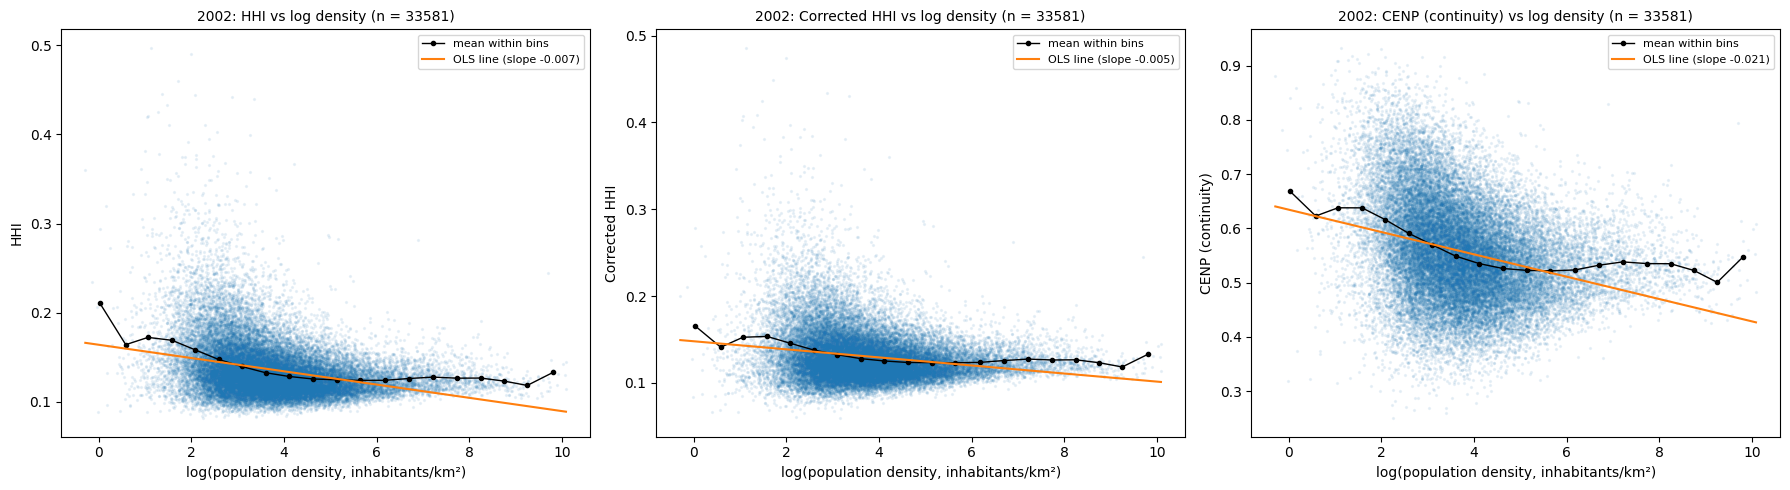

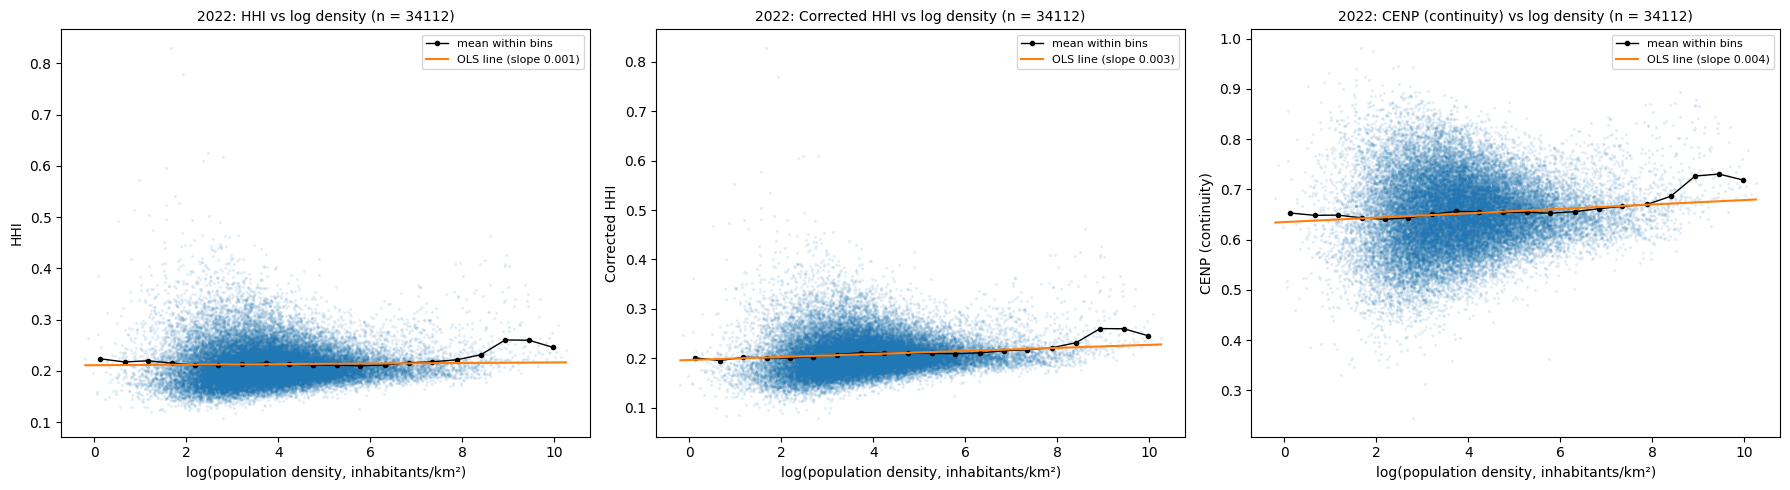

In [2]:
for year in YEARS:
    sub = main[main["year"] == year]
    fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(18, 5))
    for ax, (y, label) in zip(axes, OUTCOMES.items()):
        d = sub.dropna(subset=[y])
        commune_scatter(d, y, ax, f"{year}: {label} vs log density (n = {len(d)})", label)
    show_plot(fig)

In [3]:
pd.concat({y: pd.DataFrame({year: association_stats(main[main["year"] == year], y, weighted=True) for year in YEARS})
           for y in OUTCOMES}, axis=1)

HHI                HHI_corrected                         CENP              
                      2002          2022           2002           2022          2002          2022
n             33581.000000  3.411200e+04   3.358100e+04   3.411200e+04  33581.000000  3.411200e+04
pearson_r        -0.305963  1.851591e-02  -2.047867e-01   1.049870e-01     -0.287421  8.180033e-02
pearson_p         0.000000  6.263240e-04  8.681666e-315   3.304928e-84      0.000000  9.831408e-52
spearman_rho     -0.310497  7.698481e-02  -1.721781e-01   1.683208e-01     -0.310497  7.698489e-02
spearman_p        0.000000  5.226803e-46  9.384856e-222  3.370131e-215      0.000000  5.225800e-46
ols_coef         -0.007443  5.457634e-04  -4.648450e-03   3.070712e-03     -0.020573  4.379877e-03
ols_se            0.000126  1.595674e-04   1.212466e-04   1.574910e-04      0.000374  2.889403e-04
ols_se_HC1        0.000144  1.784442e-04   1.332551e-04   1.739769e-04      0.000381  2.932182e-04
ols_p             0.000000  6.263240e-04   0.000000e+00   3.304928e-84      0.000000  9.831408e-52
ols_p_HC1         0.000000  2.226540e-03  6.302480e-262   2.068788e-69      0.000000  2.720541e-50
ols_R2            0.093613  3.428388e-04   4.193758e-02   1.102227e-02      0.082611  6.691294e-03
wls_coef         -0.000935  4.997717e-03  -2.879633e-04   5.490112e-03     -0.001673  9.653247e-03
wls_se_HC1        0.000310  3.892663e-04   2.774658e-04   3.806521e-04      0.001192  6.658592e-04
wls_p_HC1         0.002516  9.938752e-38   2.993475e-01   3.713313e-47      0.160366  1.257717e-47
wls_R2            0.010333  9.321889e-02   1.021236e-03   1.116208e-01      0.002605  1.152174e-01

In [4]:
for year in YEARS:
    print(f"===== {year}: HHI ~ log_density =====")
    print(smf.ols("HHI ~ log_density", data=main[main["year"] == year]).fit().summary())

===== 2002: HHI ~ log_density =====
                            OLS Regression Results                            
Dep. Variable:                    HHI   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     3468.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:23:55   Log-Likelihood:                 70690.
No. Observations:               33581   AIC:                        -1.414e+05
Df Residuals:                   33579   BIC:                        -1.414e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     

In [5]:
# 2002 robustness: including communes flagged as possible boundary changes / density from the 1999 census count
all_matched_2002 = merged[(merged["year"] == 2002) & merged["metropolitan"] & merged["insee_match"]
                          & np.isfinite(merged["log_density"]) & merged["CENP"].notna()].copy()
census99 = all_matched_2002.assign(density=all_matched_2002["population"] / all_matched_2002["surface_km2"])
with np.errstate(divide="ignore"):
    census99["log_density"] = np.log(census99["density"])
pd.concat({y: pd.DataFrame({
    "main sample": association_stats(main[main["year"] == 2002], y),
    "incl. flagged boundary changes": association_stats(all_matched_2002, y),
    "incl. flagged, 1999 census population": association_stats(census99[np.isfinite(census99["log_density"])], y),
}) for y in OUTCOMES}, axis=1)

HHI                                                                       HHI_corrected                                                                               CENP  \
               main sample incl. flagged boundary changes incl. flagged, 1999 census population    main sample incl. flagged boundary changes incl. flagged, 1999 census population   main sample   
n             33581.000000                   34717.000000                          34717.000000   3.358100e+04                   3.471600e+04                          3.471600e+04  33581.000000   
pearson_r        -0.305963                      -0.318614                             -0.315177  -2.047867e-01                  -2.180946e-01                         -2.145402e-01     -0.287421   
pearson_p         0.000000                       0.000000                              0.000000  8.681666e-315                   0.000000e+00                          0.000000e+00      0.000000   
spearman_rho     -0.310497                      -0.328400                             -0.324935  -1.721781e-01                  -1.830150e-01                         -1.792653e-01     -0.310497   
spearman_p        0.000000                       0.000000                              0.000000  9.384856e-222                  3.635735e-259                         1.435263e-248      0.000000   
ols_coef         -0.007443                      -0.008373                             -0.008283  -4.648450e-03                  -5.296842e-03                         -5.210310e-03     -0.020573   
ols_se            0.000126                       0.000134                              0.000134   1.212466e-04                   1.272147e-04                          1.273123e-04      0.000374   
ols_se_HC1        0.000144                       0.000167                              0.000167   1.332551e-04                   1.535431e-04                          1.533864e-04      0.000381   
ols_p             0.000000                       0.000000                              0.000000   0.000000e+00                   0.000000e+00                          0.000000e+00      0.000000   
ols_p_HC1         0.000000                       0.000000                              0.000000  6.302480e-262                  1.910196e-256                         7.833354e-249      0.000000   
ols_R2            0.093613                       0.101515                              0.099337   4.193758e-02                   4.756525e-02                          4.602751e-02      0.082611   

                                                                                   
             incl. flagged boundary changes incl. flagged, 1999 census population  
n                              34717.000000                          34717.000000  
pearson_r                         -0.309756                             -0.305727  
pearson_p                          0.000000                              0.000000  
spearman_rho                      -0.328400                             -0.324935  
spearman_p                         0.000000                              0.000000  
ols_coef                          -0.022078                             -0.021790  
ols_se                             0.000364                              0.000364  
ols_se_HC1                         0.000378                              0.000377  
ols_p                              0.000000                              0.000000  
ols_p_HC1                          0.000000                              0.000000  
ols_R2                             0.095949                              0.093469

## 2. Density deciles (within each year)

In [6]:
main["density_decile"] = main.groupby("year")["density"].transform(lambda s: pd.qcut(s, 10, labels=False) + 1)
by_decile = main.groupby(["year", "density_decile"]).agg(
    n_communes=("commune_code", "size"), density_median=("density", "median"),
    expressed_median=("expressed", "median"),
    HHI_mean=("HHI", "mean"), HHI_median=("HHI", "median"),
    HHI_corrected_mean=("HHI_corrected", "mean"), HHI_corrected_median=("HHI_corrected", "median"),
    CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
    cliff_magnitude_mean=("cliff_magnitude", "mean"), cliff_ratio_mean=("cliff_ratio", "mean"),
)
by_decile

n_communes  density_median  expressed_median  HHI_mean  HHI_median  HHI_corrected_mean  HHI_corrected_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean
year density_decile                                                                                                                                                                              
2002 1                     3359        7.745410              79.0  0.160621    0.148669            0.146970              0.136650   0.620030     0.618242              0.122623          0.892995
     2                     3358       13.158763             107.0  0.148055    0.139325            0.138189              0.130080   0.592064     0.588170              0.108931          0.888559
     3                     3358       18.043161             129.0  0.142431    0.136067            0.134315              0.128606   0.578289     0.576713              0.102995          0.886310
     4                     3358       24.256334             161.0  0.138118    0.132257            0.131504              0.126003   0.565522     0.562598              0.099200          0.885553
     5                     3358       32.312145             204.0  0.135028    0.129883            0.129710              0.124882   0.556424     0.553385              0.095764          0.885001
     6                     3358       43.116982             261.0  0.130447    0.126658            0.126317              0.122917   0.541811     0.540314              0.090462          0.881550
     7                     3358       58.956222             329.0  0.128742    0.124715            0.125401              0.121903   0.535960     0.532116              0.089218          0.882133
     8                     3358       86.035781             449.0  0.126185    0.123296            0.123697              0.121137   0.528123     0.525961              0.085474          0.881414
     9                     3358      147.611220             720.0  0.124996    0.122136            0.123395              0.120552   0.523340     0.520825              0.084224          0.881505
     10                    3358      476.871573            2180.5  0.124986    0.122427            0.124350              0.121952   0.526477     0.522123              0.081298          0.881823
2022 1                     3412        7.323615              79.0  0.213238    0.201691            0.200359              0.189824   0.641915     0.640174              0.153729          0.873161
     2                     3411       13.219616             115.0  0.211459    0.201552            0.202812              0.193676   0.643207     0.639863              0.152339          0.876911
     3                     3411       19.088319             144.0  0.210634    0.201990            0.203880              0.195836   0.643709     0.640841              0.150423          0.877730
     4                     3411       26.271186             187.0  0.214660    0.206280            0.209375              0.201624   0.653456     0.650201              0.154685          0.880330
     5                     3411       35.794183             233.0  0.214736    0.208577            0.210507              0.205047   0.654998     0.655054              0.154293          0.881173
     6                     3411       48.412698             318.0  0.214307    0.208214            0.211153              0.205473   0.656060     0.654296              0.152422          0.881761
     7                     3411       67.307692             415.0  0.212401    0.207942            0.209984              0.205911   0.654064     0.653723              0.147838          0.879696
     8                     3411       98.936170             561.0  0.212479    0.208210            0.210671              0.206826   0.655712     0.654286              0.149123          0.880691
     9                     3411      169.163763             906.0  0.211026    0.207110            0.209875              0.206157   0.654196 

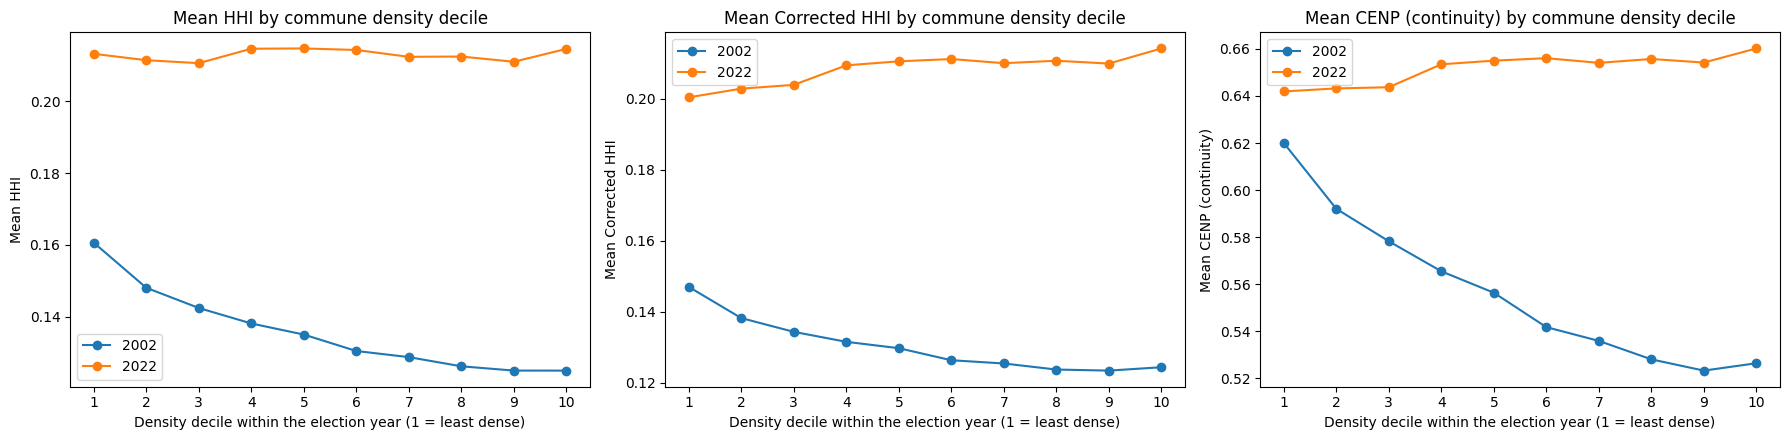

In [7]:
fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(18, 4.5))
for ax, (y, label) in zip(axes, OUTCOMES.items()):
    for year in YEARS:
        ax.plot(by_decile.loc[year].index, by_decile.loc[year][f"{y}_mean"], "o-", label=str(year))
    ax.set_xticks(range(1, 11))
    ax.set_xlabel("Density decile within the election year (1 = least dense)")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(f"Mean {label} by commune density decile")
    ax.legend()
show_plot(fig)

## 3. Small-commune robustness

Concentration measures of communes with few voters are noisy, and the noise mechanically **raises** observed HHI (and
CENP). Two complementary checks: the same statistics for several minimum numbers of expressed votes — none of these
cutoffs is "the right one" — and the corrected HHI, which removes the expected finite-electorate term. If the
density association of HHI survives in corrected HHI and above the cutoffs, it is not a small-electorate artefact.

In [8]:
CUTOFFS = [0, 100, 500, 1000]
rows = []
for y in OUTCOMES:
    for year in YEARS:
        for cutoff in CUTOFFS:
            sub = main[(main["year"] == year) & (main["expressed"] >= cutoff)]
            rows.append({"outcome": y, "year": year, "min_expressed": cutoff,
                         **association_stats(sub, y, weighted=True)})
robustness = pd.DataFrame(rows).set_index(["outcome", "year", "min_expressed"])
robustness[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se", "ols_se_HC1", "ols_p", "ols_R2",
            "wls_coef", "wls_se_HC1", "wls_p_HC1"]]

n  pearson_r  spearman_rho  ols_coef    ols_se  ols_se_HC1          ols_p    ols_R2  wls_coef  wls_se_HC1     wls_p_HC1
outcome       year min_expressed                                                                                                                             
HHI           2002 0              33581  -0.305963     -0.310497 -0.007443  0.000126    0.000144   0.000000e+00  0.093613 -0.000935    0.000310  2.515693e-03
                   100            27033  -0.194110     -0.185130 -0.003679  0.000113    0.000118  9.107836e-228  0.037679 -0.000547    0.000295  6.350866e-02
                   500             9350  -0.034921     -0.020886 -0.000468  0.000139    0.000143   7.319448e-04  0.001220  0.000287    0.000321  3.704010e-01
                   1000            4823   0.011751      0.041464  0.000148  0.000182    0.000191   4.145689e-01  0.000138  0.000392    0.000381  3.032174e-01
              2022 0              34112   0.018516      0.076985  0.000546  0.000160    0.000178   6.263240e-04  0.000343  0.004998    0.000389  9.938752e-38
                   100            28203   0.121570      0.148970  0.003241  0.000158    0.000171   2.573856e-93  0.014779  0.005284    0.000393  2.688057e-41
                   500            11333   0.242737      0.186515  0.005355  0.000201    0.000268  1.168362e-151  0.058921  0.006545    0.000453  3.197266e-47
                   1000            6133   0.286576      0.194656  0.006272  0.000268    0.000374  2.895050e-116  0.082126  0.007378    0.000524  4.251103e-45
HHI_corrected 2002 0              33581  -0.204787     -0.172178 -0.004648  0.000121    0.000133   0.000000e+00  0.041938 -0.000288    0.000277  2.993475e-01
                   100            27033  -0.132557     -0.106450 -0.002474  0.000113    0.000117  3.217539e-106  0.017571 -0.000051    0.000273  8.510804e-01
                   500             9350  -0.015780      0.000947 -0.000212  0.000139    0.000143   1.270687e-01  0.000249  0.000472    0.000314  1.326831e-01
                   1000            4823   0.021453      0.052899  0.000271  0.000182    0.000191   1.363099e-01  0.000460  0.000499    0.000378  1.863115e-01
              2022 0              34112   0.104987      0.168321  0.003071  0.000157    0.000174   3.304928e-84  0.011022  0.005490    0.000381  3.713313e-47
                   100            28203   0.161943      0.193044  0.004328  0.000157    0.000170  5.304371e-165  0.026225  0.005665    0.000387  1.996794e-48
                   500            11333   0.252673      0.197882  0.005588  0.000201    0.000268  1.398209e-164  0.063844  0.006696    0.000453  2.345949e-49
                   1000            6133   0.291218      0.200353  0.006382  0.000268    0.000374  3.618904e-120  0.084808  0.007467    0.000524  4.622856e-46
CENP          2002 0              33581  -0.287421     -0.310497 -0.020573  0.000374    0.000381   0.000000e+00  0.082611 -0.001673    0.001192  1.603657e-01
                   100            27033  -0.165327     -0.185130 -0.010812  0.000392    0.000383  6.256148e-165  0.027333 -0.000539    0.001155  6.404903e-01
                   500             9350  -0.011884     -0.020886 -0.000620  0.000540    0.000527   2.505448e-01  0.000141  0.002142    0.001281  9.438597e-02
                   1000            4823   0.033659      0.041464  0.001639  0.000701    0.000700   1.940649e-02  0.001133  0.002401    0.001530  1.166298e-01
              2022 0              34112   0.081800      0.076985  0.004380  0.000289    0.000293   9.831408e-52  0.006691  0.009653    0.000666  1.257717e-47
                   100            28203   0.162517      0.148970  0.008358  0.000302    0.000301  3.564207e-166  0.026412  0.010059    0.000664  6.557795e-52
                   500            11333   0.243370      0.186515  0.010296  0.000385    0.000430  1.824303e-152  0.059229  0.011832    0.000720  1.177141e-60
                   1000            6133   0.276897      0.194656  0.010986  0.000487    

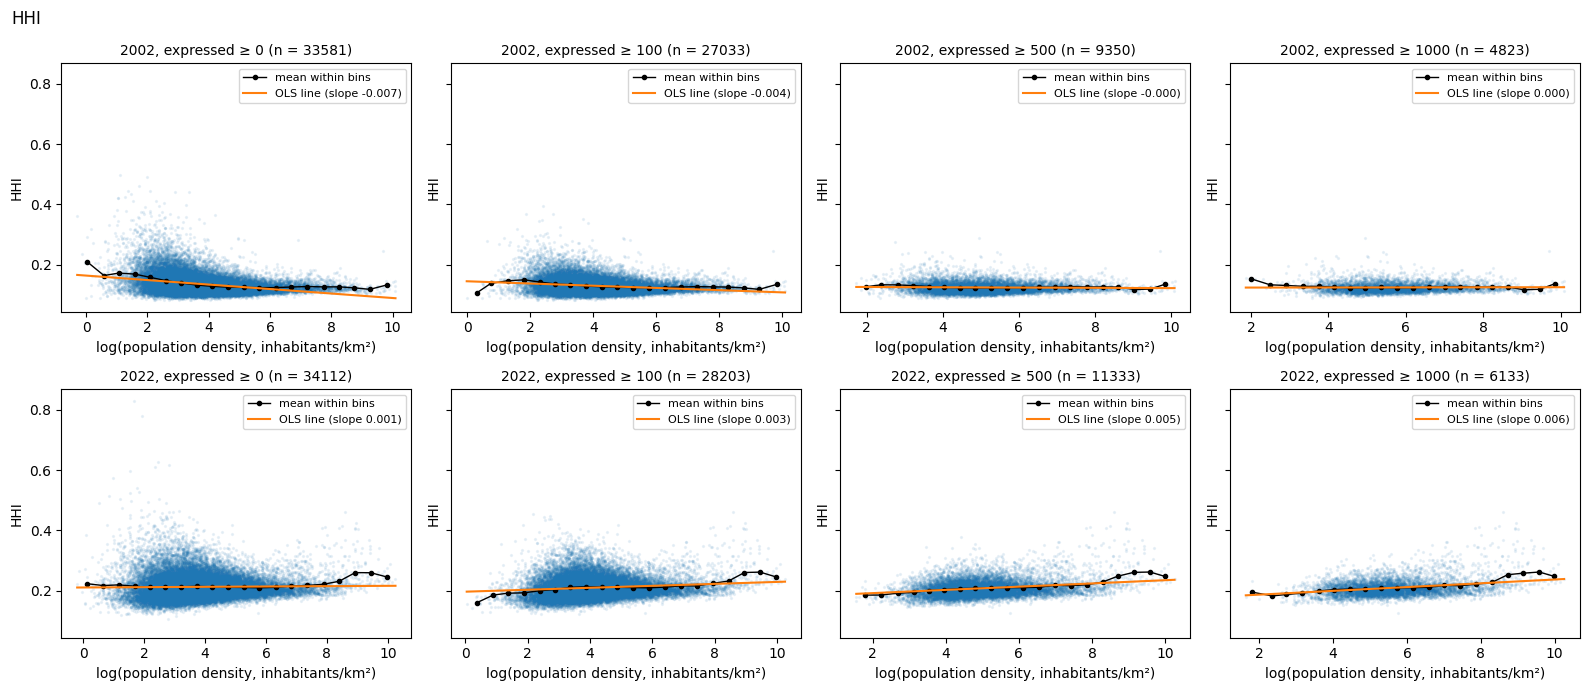

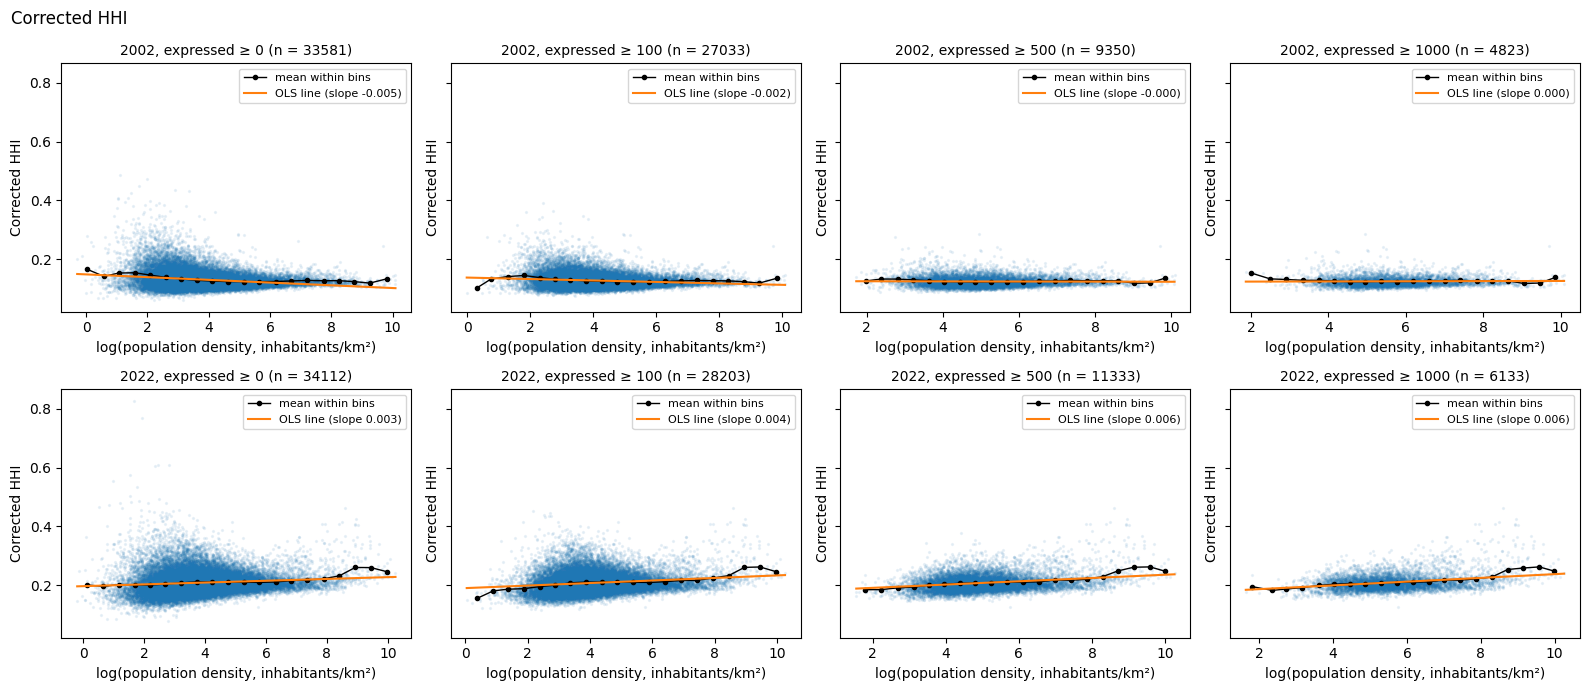

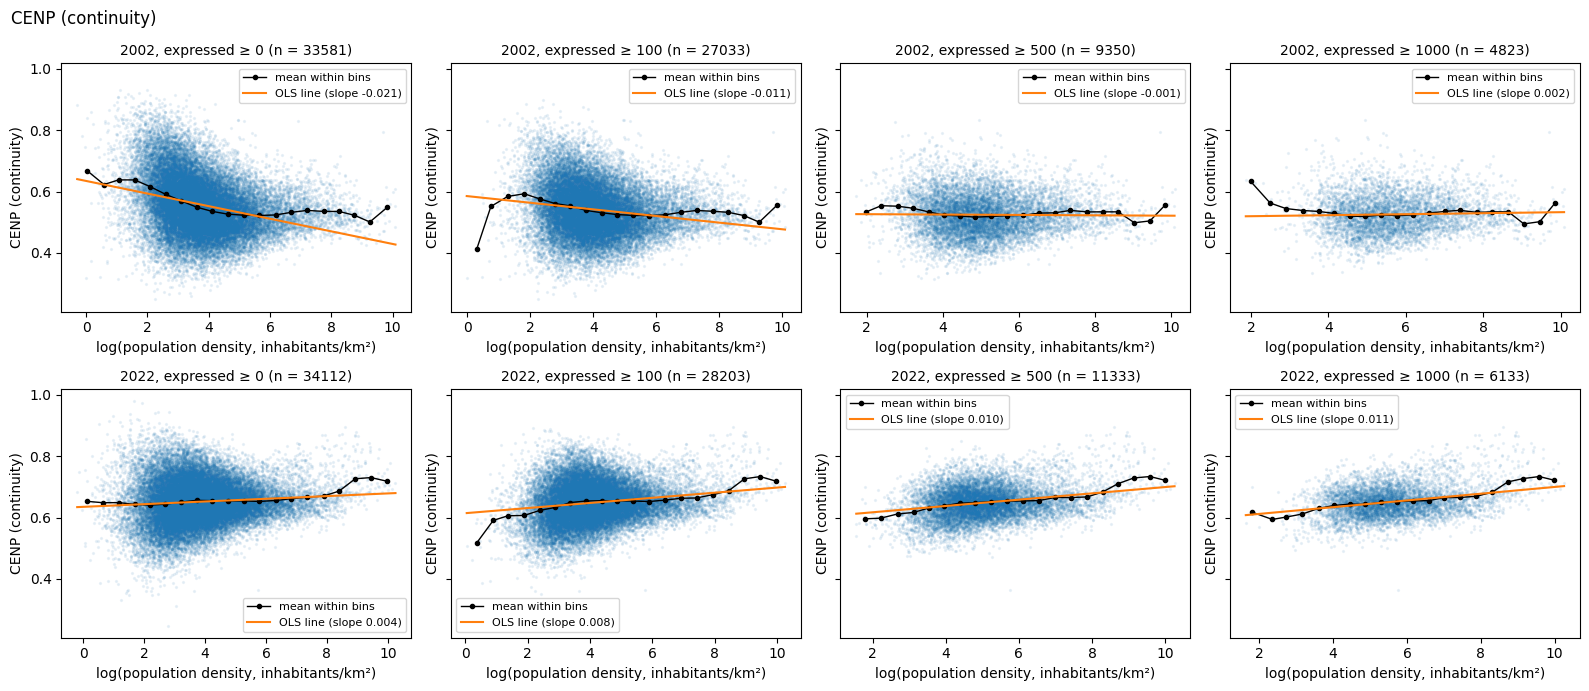

In [9]:
for y, label in OUTCOMES.items():
    fig, axes = plt.subplots(len(YEARS), len(CUTOFFS), figsize=(16, 7), sharey=True)
    for i, year in enumerate(YEARS):
        for j, cutoff in enumerate(CUTOFFS):
            sub = main[(main["year"] == year) & (main["expressed"] >= cutoff)].dropna(subset=[y])
            commune_scatter(sub, y, axes[i, j], f"{year}, expressed ≥ {cutoff} (n = {len(sub)})", label)
    fig.suptitle(label, fontsize=12, x=0.01, ha="left")
    show_plot(fig)

### Within départements

$y_i = \beta\,\log\text{density}_i + \alpha_{d(i)} + \varepsilon_i$, with département fixed effects, communes with
`expressed ≥ 500` and `≥ 1000` (the audit notebook reports more samples). HC1 and département-clustered SE.

In [10]:
FE_THRESHOLDS = [500, 1000]
pd.DataFrame([{"outcome": y, "year": year, "min_expressed": t,
               **fe_stats(main[(main["year"] == year) & (main["expressed"] >= t)], y)}
              for y in OUTCOMES for year in YEARS for t in FE_THRESHOLDS]
             ).set_index(["outcome", "year", "min_expressed"])

n  n_departements      coef    se_HC1         p_HC1  se_cluster_dep  p_cluster_dep        R2  coef_without_FE
outcome       year min_expressed                                                                                                                   
HHI           2002 500             9350              96 -0.000402  0.000146  5.919378e-03        0.000365       0.269931  0.245669        -0.000468
                   1000            4823              96  0.000457  0.000202  2.372347e-02        0.000363       0.207434  0.279486         0.000148
              2022 500            11333              96  0.001872  0.000205  6.373760e-20        0.000596       0.001690  0.464895         0.005355
                   1000            6133              96  0.002297  0.000279  1.782715e-16        0.000657       0.000468  0.472446         0.006272
HHI_corrected 2002 500             9350              96 -0.000097  0.000146  5.063258e-01        0.000367       0.791009  0.244349        -0.000212
                   1000            4823              96  0.000608  0.000202  2.628210e-03        0.000364       0.094398  0.279465         0.000271
              2022 500            11333              96  0.002140  0.000205  1.686407e-25        0.000598       0.000347  0.466611         0.005588
                   1000            6133              96  0.002429  0.000279  3.219415e-18        0.000658       0.000223  0.473633         0.006382
CENP          2002 500             9350              96 -0.000530  0.000565  3.485711e-01        0.001400       0.705070  0.240341        -0.000620
                   1000            4823              96  0.002913  0.000772  1.600913e-04        0.001354       0.031410  0.281124         0.001639
              2022 500            11333              96  0.004148  0.000366  8.420571e-30        0.001005       0.000037  0.502261         0.010296
                   1000            6133              96  0.004505  0.000488  2.796682e-20        0.001064       0.000023  0.513542         0.010986

## 4. Comparing the 2002 and 2022 relationships

Pooled regression on the main samples, for each outcome:

$$y_{it} = \beta_0 + \beta_1 \log\text{density}_{it} + \beta_2 \mathbb{1}[t=2022] + \beta_3 \log\text{density}_{it}\times\mathbb{1}[t=2022] + \varepsilon_{it}$$

$\beta_3$ = how much the density slope differs in 2022. With HHI both elections are on the same scale whatever the
number of candidates; CENP depends on $K$ (16 vs 12), so its slopes are kept for continuity only. Standard errors
clustered by département. Descriptive: a larger 2022 slope is an association, not evidence that density causes
strategic voting.

In [11]:
TERM = "log_density:C(year)[T.2022]"
pooled_data = main[[*OUTCOMES, "log_density", "year", "department_code", "expressed"]].copy()
print("HHI:")
print(pooled_interaction(pooled_data, y="HHI").summary().tables[1])

rows = []
for y in OUTCOMES:
    for cutoff in CUTOFFS:
        d = pooled_data[pooled_data["expressed"] >= cutoff]
        fit = pooled_interaction(d, y=y)
        rows.append({"outcome": y, "min_expressed": cutoff, "n": int(fit.nobs), "slope_2002": fit.params["log_density"],
                     "slope_2022": fit.params["log_density"] + fit.params[TERM], "difference_2022": fit.params[TERM],
                     "se_cluster": fit.bse[TERM], "p_cluster": fit.pvalues[TERM]})
pd.DataFrame(rows).set_index(["outcome", "min_expressed"])

HHI:
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.1641      0.003     48.627      0.000       0.157       0.171
C(year)[T.2022]                 0.0468      0.005      9.087      0.000       0.037       0.057
log_density                    -0.0074      0.001    -10.682      0.000      -0.009      -0.006
log_density:C(year)[T.2022]     0.0080      0.001      7.814      0.000       0.006       0.010


n  slope_2002  slope_2022  difference_2022  se_cluster     p_cluster
outcome       min_expressed                                                                          
HHI           0              67693   -0.007443    0.000546         0.007989    0.001022  5.537828e-15
              100            55236   -0.003679    0.003241         0.006920    0.001100  3.114308e-10
              500            20683   -0.000468    0.005355         0.005823    0.001144  3.580396e-07
              1000           10956    0.000148    0.006272         0.006124    0.001416  1.531909e-05
HHI_corrected 0              67693   -0.004648    0.003071         0.007719    0.001041  1.218830e-13
              100            55236   -0.002474    0.004328         0.006802    0.001106  7.818273e-10
              500            20683   -0.000212    0.005588         0.005799    0.001144  4.010728e-07
              1000           10956    0.000271    0.006382         0.006111    0.001417  1.608144e-05
CENP          0              67693   -0.020573    0.004380         0.024953    0.002134  1.380653e-31
              100            55236   -0.010812    0.008358         0.019170    0.002445  4.433921e-15
              500            20683   -0.000620    0.010296         0.010916    0.002174  5.131364e-07
              1000           10956    0.001639    0.010986         0.009347    0.002549  2.452025e-04

## 5. Secondary cliff measures

`cliff_magnitude` and `cliff_ratio`: same descriptive analysis as HHI (complements, not replacements).
`cliff_location` is discrete: distribution by year and across density deciles, no OLS.

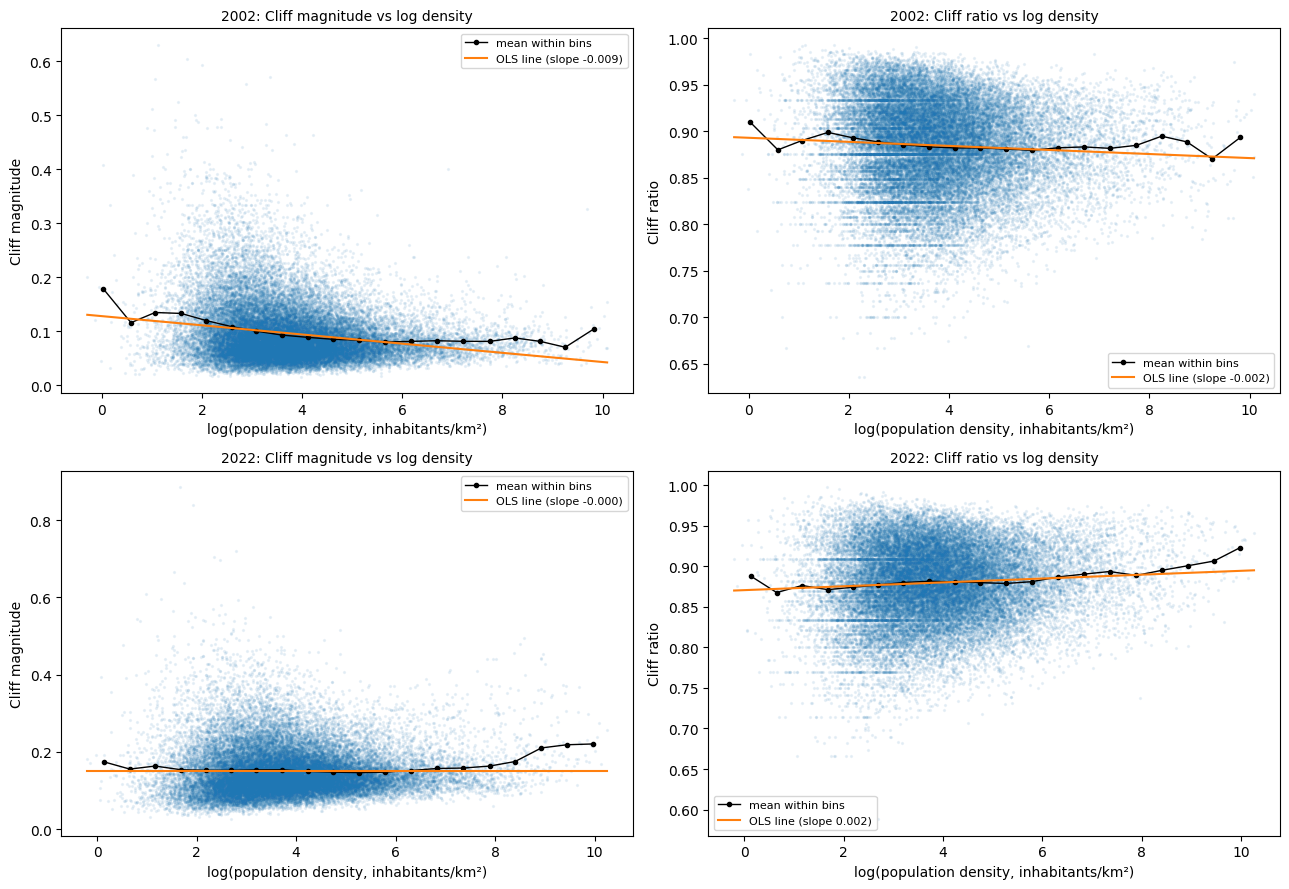

2002                                                      2022                                            
                       HHI          CENP cliff_magnitude   cliff_ratio           HHI          CENP cliff_magnitude   cliff_ratio
n             33581.000000  33581.000000    3.358100e+04  3.358100e+04  3.411200e+04  3.411200e+04    3.411200e+04  3.411200e+04
pearson_r        -0.305963     -0.287421   -2.045215e-01 -5.765684e-02  1.851591e-02  8.180033e-02   -4.694487e-06  6.821140e-02
pearson_p         0.000000      0.000000   5.823275e-314  3.929824e-26  6.263240e-04  9.831408e-52    9.993082e-01  1.802088e-36
spearman_rho     -0.310497     -0.310497   -1.695818e-01 -8.580169e-02  7.698481e-02  7.698489e-02    4.481965e-02  3.879212e-02
spearman_p        0.000000      0.000000   4.401589e-215  6.682782e-56  5.226803e-46  5.225800e-46    1.213336e-16  7.659204e-13
ols_coef         -0.007443     -0.020573   -8.501983e-03 -2.179113e-03  5.457634e-04  4.379877e-03   -2.248282e-07  2.385231e-03
ols_se            0.000126      0.000374    2.220592e-04  2.059074e-04  1.595674e-04  2.889403e-04    2.593116e-04  1.888947e-04
ols_se_HC1        0.000144      0.000381    2.323304e-04  1.982062e-04  1.784442e-04  2.932182e-04    2.902453e-04  1.919057e-04
ols_p             0.000000      0.000000    0.000000e+00  3.929824e-26  6.263240e-04  9.831408e-52    9.993082e-01  1.802088e-36
ols_p_HC1         0.000000      0.000000   1.597004e-287  4.551660e-28  2.226540e-03  2.720541e-50    9.993820e-01  2.165417e-35
ols_R2            0.093613      0.082611    4.182904e-02  3.324311e-03  3.428388e-04  6.691294e-03    2.203671e-11  4.652796e-03

In [12]:
SECONDARY = {"cliff_magnitude": "Cliff magnitude", "cliff_ratio": "Cliff ratio"}
fig, axes = plt.subplots(len(YEARS), len(SECONDARY), figsize=(13, 9))
for i, year in enumerate(YEARS):
    sub = main[main["year"] == year]
    for j, (var, label) in enumerate(SECONDARY.items()):
        commune_scatter(sub.dropna(subset=[var]), var, axes[i, j], f"{year}: {label} vs log density", label)
show_plot(fig)

pd.concat({year: pd.DataFrame({var: association_stats(main[main["year"] == year].dropna(subset=[var]), var)
                               for var in ["HHI", "CENP", *SECONDARY]})
           for year in YEARS}, axis=1)

In [13]:
print("cliff_location — distribution by year (share of communes):")
display(pd.crosstab(main["cliff_location"], main["year"], normalize="columns").round(3))
for year in YEARS:
    sub = main[main["year"] == year]
    print(f"\n{year}: cliff_location by density decile (row shares)")
    display(pd.crosstab(sub["density_decile"], sub["cliff_location"], normalize="index").round(2))

cliff_location — distribution by year (share of communes):


year,2002,2022
cliff_location,,
1.0,0.448,0.413
2.0,0.276,0.307
3.0,0.195,0.249
4.0,0.056,0.025
5.0,0.015,0.004
6.0,0.005,0.001
7.0,0.002,0.000
8.0,0.001,0.000
9.0,0.001,0.000



2002: cliff_location by density decile (row shares)


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
density_decile,,,,,,,,,,,,,,,
1,0.55,0.24,0.13,0.05,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.50,0.27,0.13,0.07,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.49,0.29,0.13,0.06,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.46,0.29,0.15,0.07,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.47,0.29,0.16,0.06,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.45,0.30,0.16,0.06,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.43,0.30,0.19,0.06,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.41,0.28,0.23,0.05,0.01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.41,0.26,0.28,0.04,0.01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



2022: cliff_location by density decile (row shares)


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,10.0
density_decile,,,,,,,,,
1,0.47,0.30,0.16,0.05,0.01,0.01,0.0,0.0,0.0
2,0.44,0.32,0.19,0.04,0.01,0.00,0.0,0.0,0.0
3,0.42,0.31,0.23,0.04,0.01,0.00,0.0,0.0,0.0
4,0.42,0.33,0.22,0.03,0.00,0.00,0.0,0.0,0.0
5,0.41,0.32,0.23,0.03,0.00,0.00,0.0,0.0,0.0
6,0.38,0.34,0.26,0.02,0.00,0.00,0.0,0.0,0.0
7,0.37,0.34,0.27,0.02,0.00,0.00,0.0,0.0,0.0
8,0.40,0.33,0.27,0.01,0.00,0.00,0.0,0.0,0.0
9,0.40,0.30,0.29,0.01,0.00,0.00,0.0,0.0,0.0
